In [1]:
import sys
sys.path.insert(0, "/ec/res4/hpcperm/itsf/git/SpectFbCalc/ClimTools")
import spectfbcalc_lib as sfc

No DISPLAY variable set. Switching to agg backend


In [2]:
from matplotlib import pyplot as plt
import xarray as xr
import yaml
import glob
from climtools import climtools_lib as ctl
import numpy as np

In [3]:
from spectfbcalc_lib import Rad_anomaly_wv_new

In [4]:
from importlib import reload
reload(sfc)

<module 'spectfbcalc_lib' from '/lus/h2resw01/hpcperm/itsf/git/SpectFbCalc/spectfbcalc/spectfbcalc_lib.py'>

In [5]:
from dask_jobqueue import SLURMCluster
from dask.distributed import Client

# Dask will automatically submit SLURM jobs for you
cluster = SLURMCluster(
    cores=4,
    memory="64GB",
    processes=4,
    walltime="01:00:00",
    #qos="np",
    #account='spitfabi',
    #interface='ib0'  # or 'eth0', depends on your HPC
    job_extra_directives=[
        "--account=spitfabi",
        "--qos=np"
        # "--constraint=haswell",
        # "--exclusive",
        # "--mail-type=END,FAIL",
        # "--mail-user=your.email@domain.com"
    ]
)

# Scale to desired number of workers
cluster.scale(jobs=4)  # This submits 4 SLURM jobs

# Connect client
client = Client(cluster)

/home/itsf/miniforge3/envs/spectfbcalc_new/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41095 instead
  warnings.warn(


In [6]:
print(client.dashboard_link)

http://10.100.192.102:41095/status


In [7]:
print(client)

<Client: 'tcp://10.100.192.102:36329' processes=0 threads=0, memory=0 B>


In [8]:
import dask.array as da
x = da.random.random((20000, 20000), chunks=(1000, 1000))
result = (x + x.T).mean().compute()
print(result)

# Subito dopo, controlla l'attività dei worker:
info = client.scheduler_info()['workers']
for addr, w in info.items():
    print(addr, "- task eseguiti:", w.get('metrics', {}).get('task_counts', 'n/a'))

1.0000203051132113
tcp://10.100.132.217:35231 - task eseguiti: {'memory': 6, 'released': 14, 'waiting': 1, 'flight': 1}
tcp://10.100.132.217:44271 - task eseguiti: {'memory': 4, 'released': 10, 'waiting': 2, 'flight': 2, 'executing': 1}
tcp://10.100.132.217:44771 - task eseguiti: {'memory': 10, 'released': 16}
tcp://10.100.132.217:46489 - task eseguiti: {'memory': 5, 'released': 2, 'waiting': 2, 'flight': 2, 'executing': 1}
tcp://10.100.134.125:35395 - task eseguiti: {'memory': 5, 'released': 16, 'executing': 1, 'waiting': 1, 'flight': 1}


In [9]:
import warnings
warnings.filterwarnings('once')

In [ ]:
config_file = 'config_zelinka.yaml'
control, experiment, kernel = sfc.preprocess_data(config_file, ker = 'SPECTRAL', wv_method_spectral='very_hybrid')

Time range for climatology: {'start': '2540-01-16 12:00:00', 'end': '2560-12-30 12:00:00'}
Time range for experiment: all
Loading kernel: SPECTRAL

 -------> Loading control
PI already remapped
Computing albedo from rsus and rsds
Converting hus to wv vmr
Creating Net TOA variables
-> rsutcs loaded
-> tas loaded
-> alb loaded
-> ta loaded
-> wv_vmr_log loaded
-> ts loaded
-> wv_vmr loaded
-> rsut loaded
-> rlutcs loaded
-> rsdt loaded
-> rlut loaded
check vertical dimension
Converting vertical coordinates from Pa to hPa

 -------> Loading experiment
4x already remapped
Computing albedo from rsus and rsds
Converting hus to wv vmr
Creating Net TOA variables
-> rsutcs loaded
-> tas loaded
-> alb loaded
-> ta loaded
-> wv_vmr_log loaded
-> ts loaded
-> wv_vmr loaded
-> rsut loaded
-> rlutcs loaded
-> rsdt loaded
-> rlut loaded
check vertical dimension
Converting vertical coordinates from Pa to hPa

 -------> Computing climatology and anomalies

 ----------> Preprocessing complete for ece3 <

In [25]:
config_file = 'config_zelinka.yaml'
control, experiment, kernel = sfc.preprocess_data(config_file, ker = 'HUANG', wv_method_spectral='spectral')

Time range for climatology: {'start': '2540-01-16 12:00:00', 'end': '2560-12-30 12:00:00'}
Time range for experiment: all
Loading kernel: HUANG

 -------> Loading control
PI already remapped
Computing albedo from rsus and rsds
Applying log to hus
Creating Net TOA variables
-> rsutcs loaded
-> hus_log loaded
-> tas loaded
-> alb loaded
-> ta loaded
-> ts loaded
-> rsut loaded
-> rlutcs loaded
-> rsdt loaded
-> rlut loaded
check vertical dimension
Converting vertical coordinates from Pa to hPa

 -------> Loading experiment
4x already remapped
Computing albedo from rsus and rsds
Applying log to hus
Creating Net TOA variables
-> rsutcs loaded
-> hus_log loaded
-> tas loaded
-> alb loaded
-> ta loaded
-> ts loaded
-> rsut loaded
-> rlutcs loaded
-> rsdt loaded
-> rlut loaded
check vertical dimension
Converting vertical coordinates from Pa to hPa

 -------> Computing climatology and anomalies

 -------> Recomputing atm dp with surface pressure

Loading surface pressure data...


/lus/h2resw01/hpcperm/itsf/git/SpectFbCalc/spectfbcalc/spectfbcalc_lib.py:635: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  surf_pressure = xr.open_mfdataset(ps_files, combine='by_coords', decode_times=time_coder, preprocess=preproc)


Surface pressure regular grid detected. Using standard regrid...
Regridding...
Regridding completed in 0:00:06.358183
Computing climatology on remapped surface pressure...
Converting surf pres from Pa to hPa
Surface pressure successfully loaded, remapped and averaged.


/lus/h2resw01/hpcperm/itsf/git/SpectFbCalc/spectfbcalc/spectfbcalc_lib.py:172: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  wid_mask = xr.DataArray(wid_mask, dims = k.dims[1:], coords = k.drop('month').coords)



 ----------> Preprocessing complete for ece3 <------------



## Spectral calc
This runs in 43 min with 4x4 workers (32 Gb each group)

After update of WV kernels, WV computes in ~13 min with 4x4 workers (64 Gb each group)

In [11]:
kernel.wv_method

'very_hybrid'

In [12]:
cart_out = '/ec/res4/hpcperm/itsf/git/SpectFbCalc/output/ece3/rad_anom_spectral_very_hybrid/'
anoms = sfc.calc_anoms(experiment, control, kernel, cart_out, use_strat_mask=False, save_pattern=False, force_recompute=False)

planck surf
Reading already computed anomaly from /ec/res4/hpcperm/itsf/git/SpectFbCalc/output/ece3/rad_anom_spectral_very_hybrid/dRt_planck-surf_global_clr.nc
planck atm
Reading already computed anomaly from /ec/res4/hpcperm/itsf/git/SpectFbCalc/output/ece3/rad_anom_spectral_very_hybrid/dRt_planck-atmo_global_clr.nc
albedo
Skipping albedo feedback for SPECTRAL kernels (not defined).
w-v
Processing clr
Before WV computation


/home/itsf/miniforge3/envs/spectfbcalc_new/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 28.93 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Computed log part: <xarray.DataArray ()> Size: 8B
array(-0.00021742)
Attributes:
    regrid_method:  bilinear - <xarray.DataArray ()> Size: 8B
array(0.02301002)
Attributes:
    regrid_method:  bilinear


/home/itsf/miniforge3/envs/spectfbcalc_new/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 29.24 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Computed lin part: <xarray.DataArray ()> Size: 8B
array(-0.00024677)
Attributes:
    regrid_method:  bilinear - <xarray.DataArray ()> Size: 8B
array(0.03980336)
Attributes:
    regrid_method:  bilinear
Processing cld
Before WV computation


/home/itsf/miniforge3/envs/spectfbcalc_new/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 28.93 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Computed log part: <xarray.DataArray ()> Size: 8B
array(-0.00029798)
Attributes:
    regrid_method:  bilinear - <xarray.DataArray ()> Size: 8B
array(0.01990296)
Attributes:
    regrid_method:  bilinear


/home/itsf/miniforge3/envs/spectfbcalc_new/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 29.24 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Computed lin part: <xarray.DataArray ()> Size: 8B
array(-0.00031538)
Attributes:
    regrid_method:  bilinear - <xarray.DataArray ()> Size: 8B
array(0.03649666)
Attributes:
    regrid_method:  bilinear


In [26]:
cart_out = '/ec/res4/hpcperm/itsf/git/SpectFbCalc/output/ece3/rad_anom_huang/'
anoms = sfc.calc_anoms(experiment, control, kernel, cart_out, use_strat_mask=False, save_pattern=False, force_recompute=False)

planck surf
Processing clr
Processing cld
planck atm
Processing clr


/home/itsf/miniforge3/envs/spectfbcalc_new/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 36.96 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Processing cld


/home/itsf/miniforge3/envs/spectfbcalc_new/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 36.96 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


albedo
w-v
Processing clr
Before WV computation


...

Processing cld
Before WV computation


/home/itsf/miniforge3/envs/spectfbcalc_new/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 47.64 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Computed


/home/itsf/miniforge3/envs/spectfbcalc_new/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 47.64 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/itsf/miniforge3/envs/spectfbcalc_new/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 71.04 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


cloud


## Compare different WV kernels

In [16]:
cart_out = '/ec/res4/hpcperm/itsf/git/SpectFbCalc/output/ece3/rad_anom_spectral_hybrid/'


In [14]:
cart_out

'/ec/res4/hpcperm/itsf/git/SpectFbCalc/output/ece3/rad_anom_spectral/'

In [17]:
##cart_out = '/ec/res4/hpcperm/itsf/git/SpectFbCalc/output/ece3/rad_anom/'
#anoms_log = sfc.open_dRt(cart_out, names = ['planck-surf', 'planck-atmo', 'lapse-rate', 'water-vapor-lw'])

#cart_out = '/ec/res4/hpcperm/itsf/git/SpectFbCalc/output/ece3/rad_anom/'
#anoms_lin = sfc.open_dRt(cart_out, names = ['planck-surf', 'planck-atmo', 'lapse-rate', 'water-vapor-lw'])

#cart_out = '/ec/res4/hpcperm/itsf/git/SpectFbCalc/output/ece3/rad_anom/'
anoms_hybrid = sfc.open_dRt(cart_out, names = ['planck-surf', 'planck-atmo', 'lapse-rate', 'water-vapor-lw'])

In [19]:
cart_out = '/ec/res4/hpcperm/itsf/git/SpectFbCalc/output/ece3/rad_anom_spectral_very_hybrid/'

anoms_very_hybrid = sfc.open_dRt(cart_out, names = ['planck-surf', 'planck-atmo', 'lapse-rate', 'water-vapor-lw'])

In [59]:
anoms_very_hybrid_int = anoms_very_hybrid['clr', 'water-vapor-lw' ].integrate('freq').groupby('time.year').mean()

In [60]:
anoms_hybrid_int = anoms_hybrid['clr', 'water-vapor-lw' ].integrate('freq').groupby('time.year').mean()

In [27]:
cart_out = '/ec/res4/hpcperm/itsf/git/SpectFbCalc/output/ece3/rad_anom_huang/'
anoms_huang = sfc.open_dRt(cart_out, names = ['planck-surf', 'planck-atmo', 'lapse-rate', 'water-vapor-lw'])

In [61]:
anoms_huang_int = anoms_huang['clr', 'water-vapor-lw'].groupby('time.year').mean()

In [55]:
anoms_hybrid_int

<xarray.DataArray 'water-vapor-lw' (year: 165)> Size: 1kB
array([ 2.39530594,  3.79867047,  4.79500278,  6.0569982 ,  6.43744217,
        6.96755412,  8.06186435,  7.88537384,  7.89441541,  8.17240913,
        9.15929017,  9.14884749,  8.96512561,  9.60386648, 10.33553602,
        8.63566297,  8.77855938, 10.33015773,  9.97307789, 10.50643766,
       11.0014945 , 10.40499904, 10.45614731, 11.15449631, 10.56911497,
       10.84117078, 12.14165831, 12.0133289 , 10.31008148, 10.49272079,
       11.41060571, 11.76453651, 12.02808523, 11.32409543, 10.95467724,
       12.75793883, 11.89722408, 10.99172133, 11.53472581, 12.46719192,
       11.95908704, 12.66142827, 11.82588481, 11.8751839 , 13.05805427,
       11.81446013, 11.64205378, 12.38185349, 13.52955333, 11.62054676,
       12.10905919, 13.82088931, 13.63194347, 12.46823615, 12.81426703,
       13.57606697, 13.85716749, 12.51827839, 12.90531594, 13.81109798,
       12.80185019, 13.2803367 , 13.27291859, 13.66675168, 14.45792495,
       13.37398408, 12.95750363, 13.60635023, 14.76851384, 13.36762482,
       13.03808078, 14.80221025, 14.32635758, 13.95998138, 14.13730611,
       14.54815618, 13.58533519, 13.4894512 , 14.92067798, 15.12203285,
       13.8911892 , 13.47615925, 14.87795252, 15.68662268, 13.70151777,
       14.00299538, 15.2022208 , 15.09374016, 13.53561809, 14.64729853,
       15.42374215, 14.37114608, 14.72705725, 15.36950412, 15.06767674,
       14.25598987, 14.61015457, 15.6482501 , 15.72009803, 13.72583739,
       14.15354137, 14.82411927, 15.67501132, 14.09874438, 15.12052717,
       14.92680915, 14.2760734 , 15.10319343, 14.02363204, 13.95289904,
       14.74688412, 14.96892696, 15.09345446, 14.74107572, 14.44271892,
       15.18822173, 16.04872032, 15.22375272, 14.65161868, 15.01505851,
       14.91416572, 14.98985133, 15.80267064, 14.8853244 , 14.44060674,
       15.14051915, 16.13733711, 14.902153  , 14.81758165, 16.3601715 ,
       15.79650463, 14.73747578, 15.20424756, 15.77391157, 15.84337623,
       15.0440267 , 15.40357536, 16.06717964, 15.44780612, 14.96140342,
       15.21121191, 15.3566974 , 15.68302276, 16.47093496, 16.65151813,
       14.88369929, 14.74700923, 16.42937735, 16.58949219, 14.95060924,
       15.01617316, 16.59585912, 15.26934573, 15.15985338, 15.91508569,
       16.80415308, 15.35014738, 15.25267217, 16.26013151, 16.90212428,
       15.52969963, 15.74283704, 16.22817234, 16.87307209, 15.36866424])
Coordinates:
  * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014

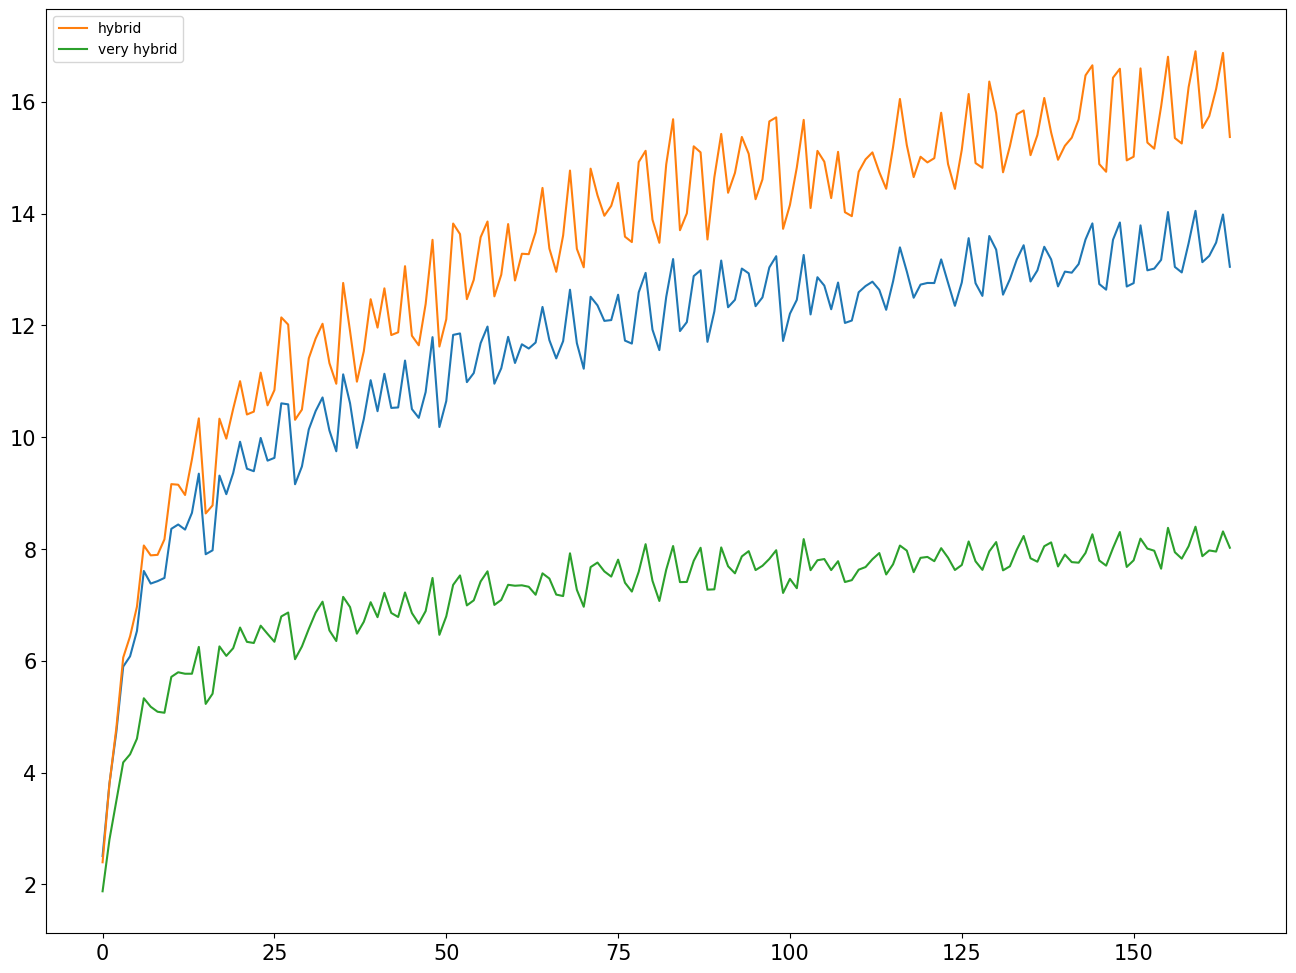

In [63]:
%matplotlib inline
plt.figure(figsize = (16,12))
plt.plot(anoms_huang_int.values*100)
plt.plot(anoms_hybrid_int.values, label = 'hybrid')
plt.plot(anoms_very_hybrid_int.values, label = 'very hybrid')

plt.legend()


array(0.02506943)

In [11]:
fb_list_1 = ['planck-surf', 'planck-all', 'lw_water-vapor']
anoms_old[('clr', 'all')] = 0.*anoms_old[('clr', fb_list[0])]
for cos in fb_list_1:
    anoms_old[('clr', 'all')] += anoms_old[('clr', cos)]

KeyError: ('clr', 'all')

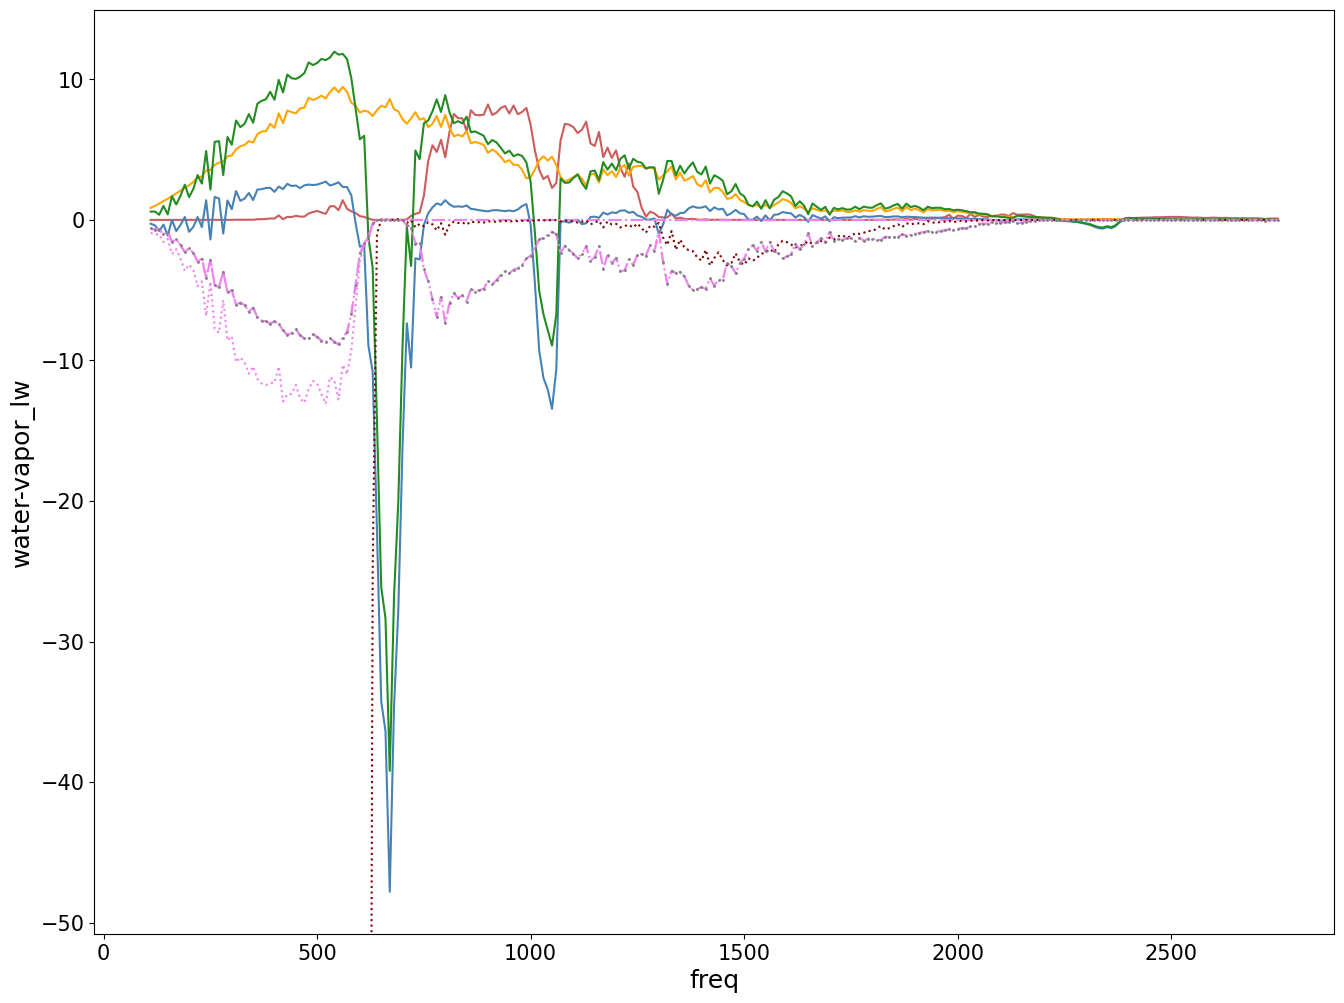

In [46]:
tip = 'clr'

plt.figure(figsize = (16,12))
for cos, col in zip(fb_list, colors + ['violet']):
    if 'water' in cos:
        anoms_lin[(tip, cos)].isel(time = slice(0, 120)).mean('time').plot(color = col, ls = ':', label = 'wv lin')
        anoms_log[(tip, cos)].isel(time = slice(0, 120)).mean('time').plot(color = col, ls = '-.', label = 'wv log')
        yli = plt.gca().get_ylim()
        (100*(anoms_log[(tip, cos)].isel(time = slice(0, 120)).mean('time'))).plot(color = 'maroon', ls = ':', label = 'wv log 2')
        plt.gca().set_ylim(yli)
        anoms_old[(tip, cos)].isel(time = slice(0, 120)).mean('time').plot(color = 'violet', label = 'wv hybrid', ls = '--')
        anoms_hybrid[(tip, cos)].isel(time = slice(0, 120)).mean('time').plot.scatter(color = 'grey', marker = 'o', s = 1, zorder = 10)
    else:
        anoms_old[(tip, cos)].isel(time = slice(0, 120)).mean('time').plot(color = col, label = cos)

anoms_old[('clr', 'all')].isel(time = slice(0, 120)).mean('time').plot(color = 'black', label = 'all')
plt.ylabel('dR (W/m2/cm-1)')

plt.legend()